In [1]:
# Import all the necessary moduls and libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

In [2]:
# Load Datasets
df = pd.read_csv("../data/Churn-Prediction-dataset.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Convert data type to int
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors='coerce'
)  

1869


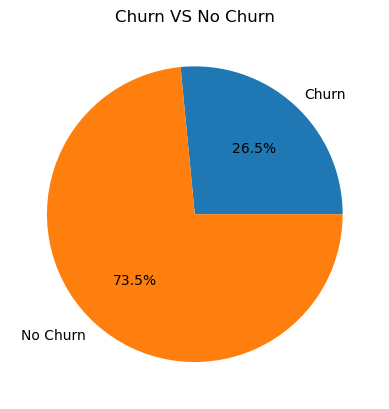

In [5]:
Churn = (df["Churn"] == "Yes").sum()
No_churn = (df["Churn"] == "No").sum()

h = Churn + No_churn + 100
x = [45,55]
print(Churn)

plt.pie([Churn, No_churn],
       labels=["Churn","No Churn"],
       autopct="%1.1f%%",
       )
plt.title("Churn VS No Churn")
plt.show()

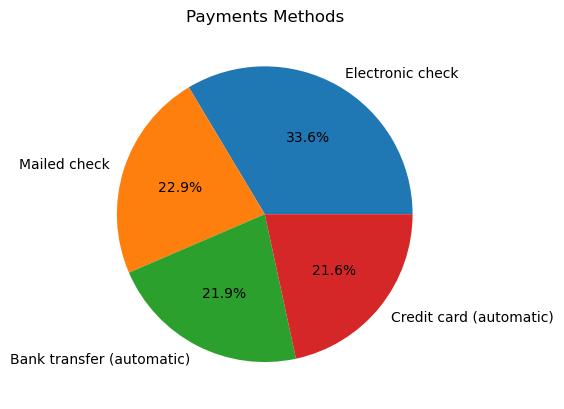

In [6]:
payment_methods = [(df["PaymentMethod"] == 'Electronic check').sum(), ((df["PaymentMethod"] == "Mailed check").sum()), (df["PaymentMethod"] == "Bank transfer (automatic)").sum(), (df["PaymentMethod"] == "Credit card (automatic)").sum()]
labels = ["Electronic check", "Mailed check", "Bank transfer (automatic)","Credit card (automatic)"]

plt.pie(payment_methods,
       labels=labels,
       autopct= "%1.1f%%"
)
plt.title("Payments Methods")
plt.show()

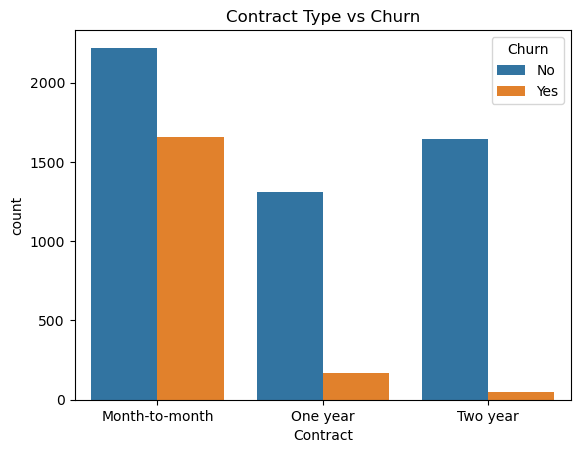

In [7]:
cont_data = pd.DataFrame({
    "Contract" : df["Contract"],
    "Churn" : df["Churn"]
})


sns.countplot(data=df, x=df["Contract"], hue=df["Churn"])
plt.title("Contract Type vs Churn")
plt.show()

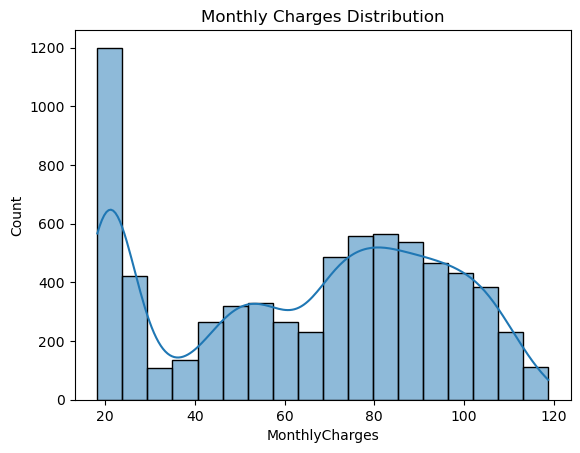

In [8]:
sns.histplot(df["MonthlyCharges"], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

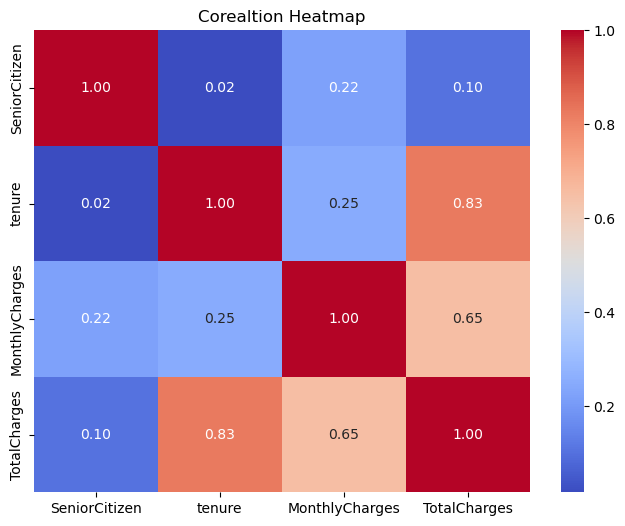

In [9]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            fmt=".2f",       
            cmap="coolwarm")
plt.title("Corealtion Heatmap")
plt.show()

In [10]:
# Split Datasets int input and output
X = df.drop(columns=['customerID','Churn'], axis=1)
y = df["Churn"]

In [11]:
# convert Churn Value into 0 and 1
y = y.map({"Yes" : 1, "No" : 0})

In [12]:
# Split Datasets into trainig and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
# Use simpleimputer to fill values
mean_imputer = SimpleImputer(strategy='mean')
X_train["TotalCharges"] = mean_imputer.fit_transform(X_train[["TotalCharges"]])
X_test["TotalCharges"] = mean_imputer.transform(X_test[["TotalCharges"]])

In [14]:
# Divide columns into binary, category and numaric based on thier value
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "gender"
]

categorical_cols  = [
    "OnlineSecurity",
    "OnlineBackup",
    "MultipleLines",
    "InternetService",
    "InternetService",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
    "DeviceProtection",
    'TechSupport',
    'StreamingTV'
]

numeric_col = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

# Preprocesser For Logistic Regression and K Nearest Neighbor

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ("binary",OrdinalEncoder(), binary_cols),
        ("cat", OneHotEncoder(drop="first",handle_unknown='ignore'), categorical_cols),
        ("num", StandardScaler(), numeric_col)
    ],
    remainder="passthrough"
)

# Logistic Regression

In [16]:
lg_model = LogisticRegression(
    C=1,
    max_iter=1000,
    penalty="l1",
    solver="liblinear"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lg_model)
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

print("Accuracy Score: ", accuracy_score(y_test, pred))
print("Precision Score: ", precision_score(y_test, pred))
print("Recall Score: ", recall_score(y_test, pred))
print("F1 Score: ", f1_score(y_test, pred))
print("ROC AUC Score: ", roc_auc_score(y_test, pred))

Accuracy Score:  0.8211497515968772
Precision Score:  0.6850152905198776
Recall Score:  0.6005361930294906
F1 Score:  0.64
ROC AUC Score:  0.7505576718043206


In [17]:
joblib.dump(pipeline, "../models/Logistic_Regression.pkl")

['../models/Logistic_Regression.pkl']

## K Nearest Neighbors

In [18]:
knn_model = KNeighborsClassifier()

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", knn_model)
])

knn_pipeline.fit(X_train, y_train)
pred = knn_pipeline.predict(X_test)


print("Accuracy Score: ", accuracy_score(y_test, pred))
print("Precision Score: ", precision_score(y_test, pred))
print("Recall Score: ", recall_score(y_test, pred))
print("F1 Score: ", f1_score(y_test, pred))
print("ROC AUC Score: ", roc_auc_score(y_test, pred))

Accuracy Score:  0.7764371894960965
Precision Score:  0.5863095238095238
Recall Score:  0.5281501340482574
F1 Score:  0.5557122708039492
ROC AUC Score:  0.6969901249391867


## Hyperparameter Tnnig For KNN

In [19]:
n_neighbors = [20, 25,30,35,40,45,50]

for n in n_neighbors:
    knn_model = KNeighborsClassifier(
        n_neighbors=n
    )
    
    knn_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", knn_model)
    ])
    
    knn_pipeline.fit(X_train, y_train)
    pred = knn_pipeline.predict(X_test)
    
    print("Score for n neigbhor for", n)
    print("Accuracy Score: ", accuracy_score(y_test, pred))
    print("Precision Score: ", precision_score(y_test, pred))
    print("Recall Score: ", recall_score(y_test, pred))
    print("F1 Score: ", f1_score(y_test, pred))
    print("ROC AUC Score: ", roc_auc_score(y_test, pred))

Score for n neigbhor for 20
Accuracy Score:  0.8048261178140526
Precision Score:  0.6611842105263158
Recall Score:  0.5388739946380697
F1 Score:  0.5937961595273265
ROC AUC Score:  0.7197265726086103
Score for n neigbhor for 25
Accuracy Score:  0.8076650106458482
Precision Score:  0.6536144578313253
Recall Score:  0.5817694369973191
F1 Score:  0.6156028368794326
ROC AUC Score:  0.7353827879967291
Score for n neigbhor for 30
Accuracy Score:  0.8041163946061036
Precision Score:  0.653968253968254
Recall Score:  0.5522788203753352
F1 Score:  0.5988372093023255
ROC AUC Score:  0.7235332325814899
Score for n neigbhor for 35
Accuracy Score:  0.8105039034776437
Precision Score:  0.6577380952380952
Recall Score:  0.5924932975871313
F1 Score:  0.6234132581100141
ROC AUC Score:  0.7407447182916351
Score for n neigbhor for 40
Accuracy Score:  0.8097941802696949
Precision Score:  0.6635514018691588
Recall Score:  0.5710455764075067
F1 Score:  0.6138328530259366
ROC AUC Score:  0.7333992360802013
S

In [20]:
leaf_size = [30,35, 40,45,50,55,60]

for n in leaf_size:
    knn_model = KNeighborsClassifier(
        n_neighbors=45,
        leaf_size=n
    )
    
    knn_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", knn_model)
    ])
    
    knn_pipeline.fit(X_train, y_train)
    pred = knn_pipeline.predict(X_test)
    
    print("Score for leaf_size for", n)
    print("Accuracy Score: ", accuracy_score(y_test, pred))
    print("Precision Score: ", precision_score(y_test, pred))
    print("Recall Score: ", recall_score(y_test, pred))
    print("F1 Score: ", f1_score(y_test, pred))
    print("ROC AUC Score: ", roc_auc_score(y_test, pred))

Score for leaf_size for 30
Accuracy Score:  0.8140525195173882
Precision Score:  0.6637168141592921
Recall Score:  0.6032171581769437
F1 Score:  0.6320224719101124
ROC AUC Score:  0.7465892740691669
Score for leaf_size for 35
Accuracy Score:  0.8140525195173882
Precision Score:  0.6637168141592921
Recall Score:  0.6032171581769437
F1 Score:  0.6320224719101124
ROC AUC Score:  0.7465892740691669
Score for leaf_size for 40
Accuracy Score:  0.8140525195173882
Precision Score:  0.6637168141592921
Recall Score:  0.6032171581769437
F1 Score:  0.6320224719101124
ROC AUC Score:  0.7465892740691669
Score for leaf_size for 45
Accuracy Score:  0.8140525195173882
Precision Score:  0.6637168141592921
Recall Score:  0.6032171581769437
F1 Score:  0.6320224719101124
ROC AUC Score:  0.7465892740691669
Score for leaf_size for 50
Accuracy Score:  0.8140525195173882
Precision Score:  0.6637168141592921
Recall Score:  0.6032171581769437
F1 Score:  0.6320224719101124
ROC AUC Score:  0.7465892740691669
Score

In [21]:
metric = ['euclidean', 'manhattan', 'minkowski']

for n in metric:
    knn_model = KNeighborsClassifier(
        n_neighbors=45,
        metric=n
    )
    
    knn_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", knn_model)
    ])
    
    knn_pipeline.fit(X_train, y_train)
    pred = knn_pipeline.predict(X_test)
    
    print("Score for metric for", n)
    print("Accuracy Score: ", accuracy_score(y_test, pred))
    print("Precision Score: ", precision_score(y_test, pred))
    print("Recall Score: ", recall_score(y_test, pred))
    print("F1 Score: ", f1_score(y_test, pred))
    print("ROC AUC Score: ", roc_auc_score(y_test, pred))

Score for metric for euclidean
Accuracy Score:  0.8140525195173882
Precision Score:  0.6637168141592921
Recall Score:  0.6032171581769437
F1 Score:  0.6320224719101124
ROC AUC Score:  0.7465892740691669
Score for metric for manhattan
Accuracy Score:  0.8140525195173882
Precision Score:  0.6666666666666666
Recall Score:  0.5951742627345844
F1 Score:  0.6288951841359773
ROC AUC Score:  0.7440157027958637
Score for metric for minkowski
Accuracy Score:  0.8140525195173882
Precision Score:  0.6637168141592921
Recall Score:  0.6032171581769437
F1 Score:  0.6320224719101124
ROC AUC Score:  0.7465892740691669


In [22]:
# KNN Best Model

knn_best_model = KNeighborsClassifier(
    n_neighbors=45
)

Knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", knn_model)
])

knn_pipeline.fit(X_train, y_train)
pred = knn_pipeline.predict(X_test)

print("Score for metric for", n)
print("Accuracy Score: ", accuracy_score(y_test, pred))
print("Precision Score: ", precision_score(y_test, pred))
print("Recall Score: ", recall_score(y_test, pred))
print("F1 Score: ", f1_score(y_test, pred))
print("ROC AUC Score: ", roc_auc_score(y_test, pred))

Score for metric for minkowski
Accuracy Score:  0.8140525195173882
Precision Score:  0.6637168141592921
Recall Score:  0.6032171581769437
F1 Score:  0.6320224719101124
ROC AUC Score:  0.7465892740691669


In [23]:
joblib.dump(knn_pipeline, '../models/KNN.pkl')

['../models/KNN.pkl']

In [ ]:
# Grid Search Cv for KNN
model = KNeighborsClassifier()

param_grid = {
    "model__n_neighbors": range(35, 61, 5),
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan", "minkowski"],
    "model__p": [1, 2]
}

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

grid = GridSearchCV(
    knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

In [ ]:
# Knn Model Based On Gridsearchcv result

grid_knn_model = KNeighborsClassifier(
    metric='manhattan',
    n_neighbors=35,
    p=1,
    weights='uniform'
)

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

knn_pipeline.fit(X_train, y_train)
pred = knn_pipeline.predict(X_test)


print("Accuracy Score: ", accuracy_score(y_test, pred))
print("Precision Score: ", precision_score(y_test, pred))
print("Recall Score: ", recall_score(y_test, pred))
print("F1 Score: ", f1_score(y_test, pred))
print("ROC AUC Score: ", roc_auc_score(y_test, pred))

# Preprocessor for Decision Tree, Random Forest, XGBoost

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("binary",OrdinalEncoder(), binary_cols),
        ("cat", OneHotEncoder(drop="first",handle_unknown='ignore'), categorical_cols)
    ],
    remainder="passthrough"
)

## Decision Tree

In [ ]:
Dt_model = DecisionTreeClassifier()

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Dt_model)
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

print("Accuracy Score: ", accuracy_score(y_test, pred))
print("Precision Score: ", precision_score(y_test, pred))
print("Recall Score: ", recall_score(y_test, pred))
print("F1 Score: ", f1_score(y_test, pred))
print("ROC AUC Score: ", roc_auc_score(y_test, pred))

## Hyperparameter Tunnig For Decision Tree

In [ ]:
for depth in [3, 5, 7, 10, 15, 20]:
    Dt_model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", Dt_model)
    ])
    
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    
    print("Accuracy Score: ", accuracy_score(y_test, pred))
    print("Precision Score: ", precision_score(y_test, pred))
    print("Recall Score: ", recall_score(y_test, pred))
    print("F1 Score: ", f1_score(y_test, pred))
    print("ROC AUC Score: ", roc_auc_score(y_test, pred))

In [ ]:
for depth in [2, 5, 10, 20]:
    Dt_model = DecisionTreeClassifier(
        max_depth=7,
        min_samples_split = depth,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", Dt_model)
    ])
    
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    print("Score For min_samples_split :", depth)
    print("Accuracy Score: ", accuracy_score(y_test, pred))
    print("Precision Score: ", precision_score(y_test, pred))
    print("Recall Score: ", recall_score(y_test, pred))
    print("F1 Score: ", f1_score(y_test, pred))
    print("ROC AUC Score: ", roc_auc_score(y_test, pred))

In [ ]:
for depth in [2, 5, 10, 20, 25]:
    Dt_model = DecisionTreeClassifier(
        max_depth=7,
        min_samples_split=20,
        random_state=42,
        min_samples_leaf = depth
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", Dt_model)
    ])
    
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    print("Score For min_samples_leaf  :", depth)
    print("Accuracy Score: ", accuracy_score(y_test, pred))
    print("Precision Score: ", precision_score(y_test, pred))
    print("Recall Score: ", recall_score(y_test, pred))
    print("F1 Score: ", f1_score(y_test, pred))
    print("ROC AUC Score: ", roc_auc_score(y_test, pred))

In [ ]:
for depth in ["gini", "entropy"]:
    Dt_model = DecisionTreeClassifier(
        max_depth=7,
        min_samples_split=20,
        random_state=42,
        min_samples_leaf = 20,
        criterion =depth
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", Dt_model)
    ])
    
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    print("Score For criterion   :", depth)
    print("Accuracy Score: ", accuracy_score(y_test, pred))
    print("Precision Score: ", precision_score(y_test, pred))
    print("Recall Score: ", recall_score(y_test, pred))
    print("F1 Score: ", f1_score(y_test, pred))
    print("ROC AUC Score: ", roc_auc_score(y_test, pred))

In [ ]:
Best_Dt_model = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=20,
    min_samples_leaf=20,
    criterion="gini",
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Best_Dt_model)
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

print("Accuracy Score: ", accuracy_score(y_test, pred))
print("Precision Score: ", precision_score(y_test, pred))
print("Recall Score: ", recall_score(y_test, pred))
print("F1 Score: ", f1_score(y_test, pred))
print("ROC AUC Score: ", roc_auc_score(y_test, pred))

In [ ]:
# Gridsearccv test

param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [5, 7, 10],
    "model__min_samples_split": [10, 20, 30],
    "model__min_samples_leaf": [10, 20, 30]
}

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

In [ ]:
grid_Dt_Model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_leaf=20,
    min_samples_split=10,
    random_state=42
)

grid_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", grid_Dt_Model)
])

grid_pipeline.fit(X_train, y_train)
pred = grid_pipeline.predict(X_test)

print("Accuracy Score: ", accuracy_score(y_test, pred))
print("Precision Score: ", precision_score(y_test, pred))
print("Recall Score: ", recall_score(y_test, pred))
print("F1 Score: ", f1_score(y_test, pred))
print("ROC AUC Score: ", roc_auc_score(y_test, pred))

In [ ]:
joblib.dump(pipeline, "../models/DecisionTreeModel.pkl")

## Random Forest

In [ ]:
RF_model = RandomForestClassifier()

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RF_model)
])

pipeline.fit(X_train, y_train)

pred = pipeline.predict(X_test)

print("Accuracy Score: ", accuracy_score(y_test, pred))
print("Precision Score: ", precision_score(y_test, pred))
print("Recall Score: ", recall_score(y_test, pred))
print("F1 Score: ", f1_score(y_test, pred))
print("ROC AUC Score: ", roc_auc_score(y_test, pred))

## Hyperparameter Tunning for Random Forest

In [ ]:
n_estimators = [25, 40, 50, 100, 200, 300]

for n in n_estimators:
    RF_model = RandomForestClassifier(
        n_estimators=n
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RF_model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    pred = pipeline.predict(X_test)

    print("Score For n_estimators   :", n)
    print("Accuracy Score: ", accuracy_score(y_test, pred))
    print("Precision Score: ", precision_score(y_test, pred))
    print("Recall Score: ", recall_score(y_test, pred))
    print("F1 Score: ", f1_score(y_test, pred))
    print("ROC AUC Score: ", roc_auc_score(y_test, pred))

In [ ]:
max_depth = [3, 5, 7, 10, 15]

for n in max_depth:
    RF_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=n,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RF_model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    pred = pipeline.predict(X_test)

    print("Score For max_depth   :", n)
    print("Accuracy Score: ", accuracy_score(y_test, pred))
    print("Precision Score: ", precision_score(y_test, pred))
    print("Recall Score: ", recall_score(y_test, pred))
    print("F1 Score: ", f1_score(y_test, pred))
    print("ROC AUC Score: ", roc_auc_score(y_test, pred))

In [ ]:
min_samples_split = [2, 5, 10, 20]

for n in min_samples_split:
    RF_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=n,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RF_model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    pred = pipeline.predict(X_test)

    print("Score For min_samples_split   :", n)
    print("Accuracy Score: ", accuracy_score(y_test, pred))
    print("Precision Score: ", precision_score(y_test, pred))
    print("Recall Score: ", recall_score(y_test, pred))
    print("F1 Score: ", f1_score(y_test, pred))
    print("ROC AUC Score: ", roc_auc_score(y_test, pred))

In [ ]:
min_samples_leaf = [1, 2, 4, 8, 10, 20]

for n in min_samples_leaf:
    RF_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=n,
        random_state=42
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RF_model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    pred = pipeline.predict(X_test)

    print("Score For min_samples_leaf   :", n)
    print("Accuracy Score: ", accuracy_score(y_test, pred))
    print("Precision Score: ", precision_score(y_test, pred))
    print("Recall Score: ", recall_score(y_test, pred))
    print("F1 Score: ", f1_score(y_test, pred))
    print("ROC AUC Score: ", roc_auc_score(y_test, pred))

In [ ]:
Best_RF_Model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42
)

RF_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Best_RF_Model)
])

RF_pipeline.fit(X_train, y_train)

pred = RF_pipeline.predict(X_test)

print("Accuracy Score: ", accuracy_score(y_test, pred))
print("Precision Score: ", precision_score(y_test, pred))
print("Recall Score: ", recall_score(y_test, pred))
print("F1 Score: ", f1_score(y_test, pred))
print("ROC AUC Score: ", roc_auc_score(y_test, pred))

In [ ]:
joblib.dump(RF_pipeline, '../models/RandomForest.pkl')

## XGBoost